In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data.csv')
df.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Remove missing values
df = df.dropna(subset=['Cuisines'])

# Standardize cuisine format (strip spaces)
df['Cuisines'] = df['Cuisines'].apply(lambda x: ', '.join(sorted([i.strip() for i in x.split(',')])))

In [4]:
# Count frequency of each cuisine combination
cuisine_counts = df['Cuisines'].value_counts()

print("Top Cuisine Combinations:")
print(cuisine_counts.head(10))

Top Cuisine Combinations:
Cuisines
North Indian                      936
Chinese, North Indian             616
Mughlai, North Indian             394
Fast Food                         354
Chinese                           354
Chinese, Mughlai, North Indian    306
Cafe                              299
Bakery                            218
Bakery, Desserts                  181
Chinese, Fast Food                159
Name: count, dtype: int64


In [5]:
# Average rating per cuisine combination
cuisine_ratings = df.groupby('Cuisines')['Aggregate rating'].mean()

# Combine count + rating
cuisine_analysis = pd.DataFrame({
    'Count': cuisine_counts,
    'Average Rating': cuisine_ratings
})

# Sort by popularity
print("Most Popular Combinations:")
print(cuisine_analysis.sort_values(by='Count', ascending=False).head(10))

# Sort by rating
print("\nHighest Rated Combinations:")
print(cuisine_analysis.sort_values(by='Average Rating', ascending=False).head(10))

Most Popular Combinations:
                                Count  Average Rating
Cuisines                                             
North Indian                      936        1.672329
Chinese, North Indian             616        2.333442
Mughlai, North Indian             394        2.767259
Chinese                           354        2.042090
Fast Food                         354        2.118362
Chinese, Mughlai, North Indian    306        2.619935
Cafe                              299        2.890970
Bakery                            218        1.924312
Bakery, Desserts                  181        2.375691
Chinese, Fast Food                159        2.069811

Highest Rated Combinations:
                                 Count  Average Rating
Cuisines                                              
World Cuisine                        1             4.9
American, BBQ, Sandwich              1             4.9
American, Healthy Food, Mexican      1             4.9
American, Coffee and 

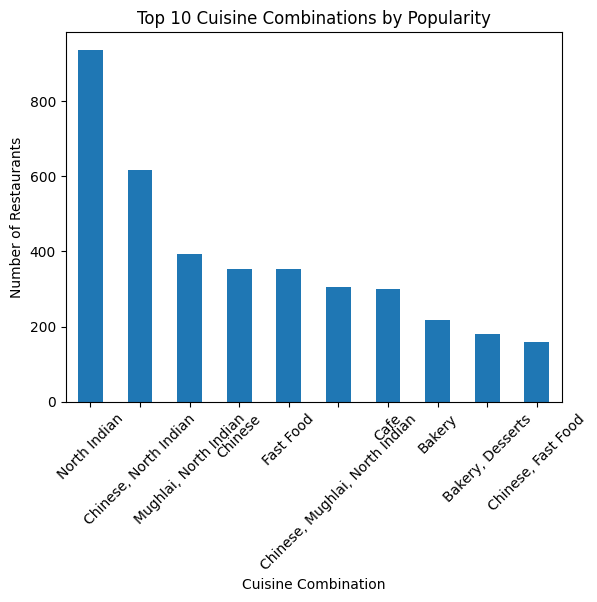

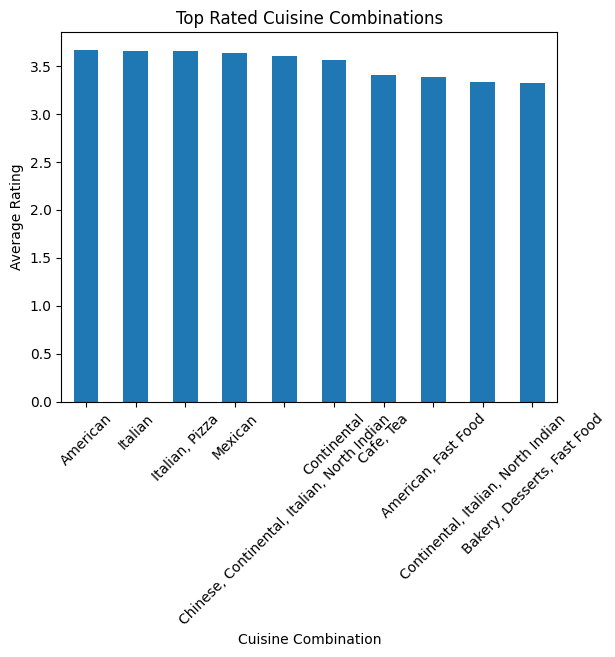

In [6]:
import matplotlib.pyplot as plt

# Top 10 most common combinations
top_common = cuisine_analysis.sort_values(by='Count', ascending=False).head(10)

plt.figure()
top_common['Count'].plot(kind='bar')
plt.title("Top 10 Cuisine Combinations by Popularity")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

# Top 10 highest rated combinations (min 20 restaurants to avoid noise)
filtered = cuisine_analysis[cuisine_analysis['Count'] > 20]
top_rated = filtered.sort_values(by='Average Rating', ascending=False).head(10)

plt.figure()
top_rated['Average Rating'].plot(kind='bar')
plt.title("Top Rated Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()